In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_data
from src.preprocessing import split_data

In [2]:
MODEL_PATH = Path("../models/xgboost_optuna.pkl").resolve()

model = joblib.load(MODEL_PATH)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [3]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df)
X_test.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType
1501,59,47802.0,24574.0,660.0,36,Male,PhD,Houston,Self-Employed
2586,25,NaN,11742.0,723.0,26,Male,High School,Houston,Salaried
2653,38,20215.0,15629.0,494.0,31,Male,High School,New York,Self-Employed
1055,48,51531.0,31439.0,809.0,21,Male,PhD,Chicago,Salaried
705,53,55114.0,10732.0,370.0,19,Male,PhD,Houston,Self-Employed


In [4]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

preprocessor, classifier

(ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience'], dtype='str')),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  Index(['Gender', 'Education', 'City', 'EmploymentType'], dtype='str'))]),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsampl

In [5]:
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

feature_names = preprocessor.get_feature_names_out()

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [6]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_processed_df)

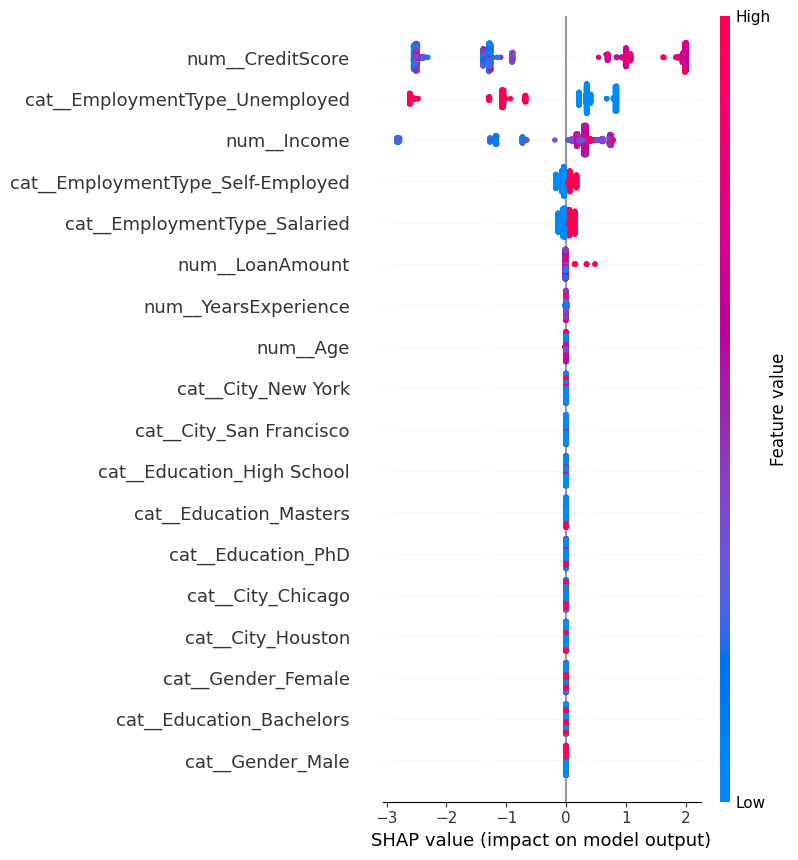

In [7]:
shap.summary_plot(shap_values, X_test_processed_df)

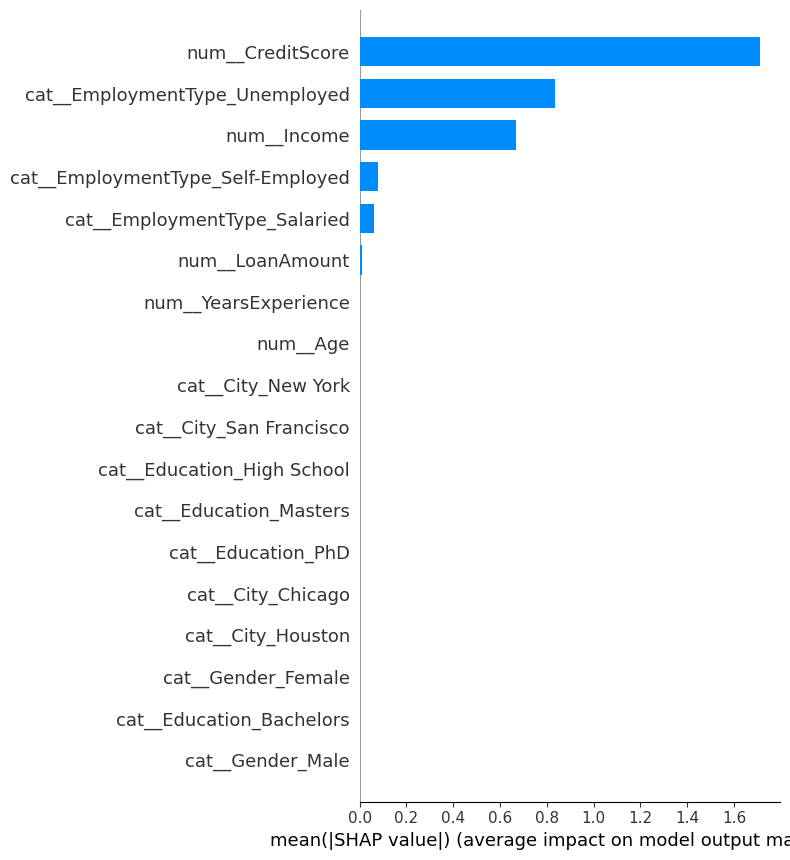

In [8]:
shap.summary_plot(shap_values, X_test_processed_df, plot_type="bar")

In [9]:
sample_idx = 0

X_sample = X_test_processed_df.iloc[[sample_idx]]
X_sample

,num__Age,num__Income,num__LoanAmount,num__CreditScore,num__YearsExperience,cat__Gender_Female,cat__Gender_Male,cat__Education_Bachelors,cat__Education_High School,cat__Education_Masters,cat__Education_PhD,cat__City_Chicago,cat__City_Houston,cat__City_New York,cat__City_San Francisco,cat__EmploymentType_Salaried,cat__EmploymentType_Self-Employed,cat__EmploymentType_Unemployed
0,1.020608,-0.129637,0.571263,0.52192,1.400024,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [10]:
shap_values_sample = explainer.shap_values(X_sample)

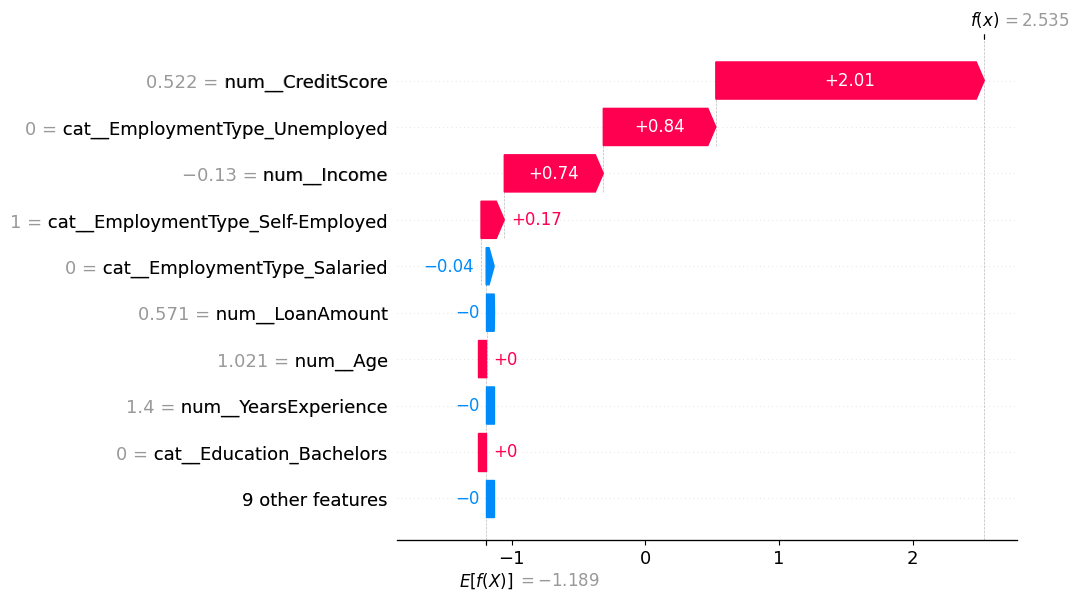

In [11]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_sample[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=X_sample.columns.tolist()
    )
)

In [12]:
pred_proba = model.predict_proba(X_test.iloc[[sample_idx]])[:, 1][0]
pred_class = model.predict(X_test.iloc[[sample_idx]])[0]

print("Predicted class:", pred_class)
print("Predicted probability:", pred_proba)
print("Actual class:", y_test.iloc[sample_idx])

Predicted class: 1
Predicted probability: 0.926565
Actual class: 1
